# Smadex Creative Dataset — Pattern Discovery

Clustering, lifecycle archetypes, joint distributions, and multi-modal correlations on the cleaned dataset. The goal is to surface **patterns a model could learn from**, not just describe the data.

**Sections**
1. Setup & data loading
2. Marginal distributions per modality
3. Lifecycle archetypes (cluster the daily CTR curves themselves)
4. Genome clustering (KMeans on tabular + early-life features)
5. UMAP visualization in 2D, colored by status / vertical / cluster
6. Top-performer vs underperformer: what differs
7. Survival of the fittest — fatigue_day distribution by cohort
8. Multi-modal correlation: visual × behavioral
9. Insight callouts

## 1 — Setup & data loading

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.width', 180)

REPO = Path('..').resolve()
DATA_ROOT = REPO.parent

summary = pd.read_csv(DATA_ROOT / 'creative_summary.csv')
creatives = pd.read_csv(DATA_ROOT / 'creatives.csv')
daily = pd.read_csv(DATA_ROOT / 'creative_daily_country_os_stats.csv', parse_dates=['date'])

STATUS_COLOR = {
    'top_performer': '#16a34a', 'stable': '#2563eb',
    'fatigued': '#ea580c', 'underperformer': '#dc2626',
}
VERTICAL_COLOR = {
    'gaming': '#8b5cf6', 'travel': '#06b6d4', 'fintech': '#10b981',
    'ecommerce': '#f59e0b', 'food_delivery': '#ef4444', 'entertainment': '#ec4899',
}

print(f'creatives: {len(creatives)}, daily: {len(daily)}')

creatives: 1080, daily: 192315


## 2 — Marginal distributions per modality

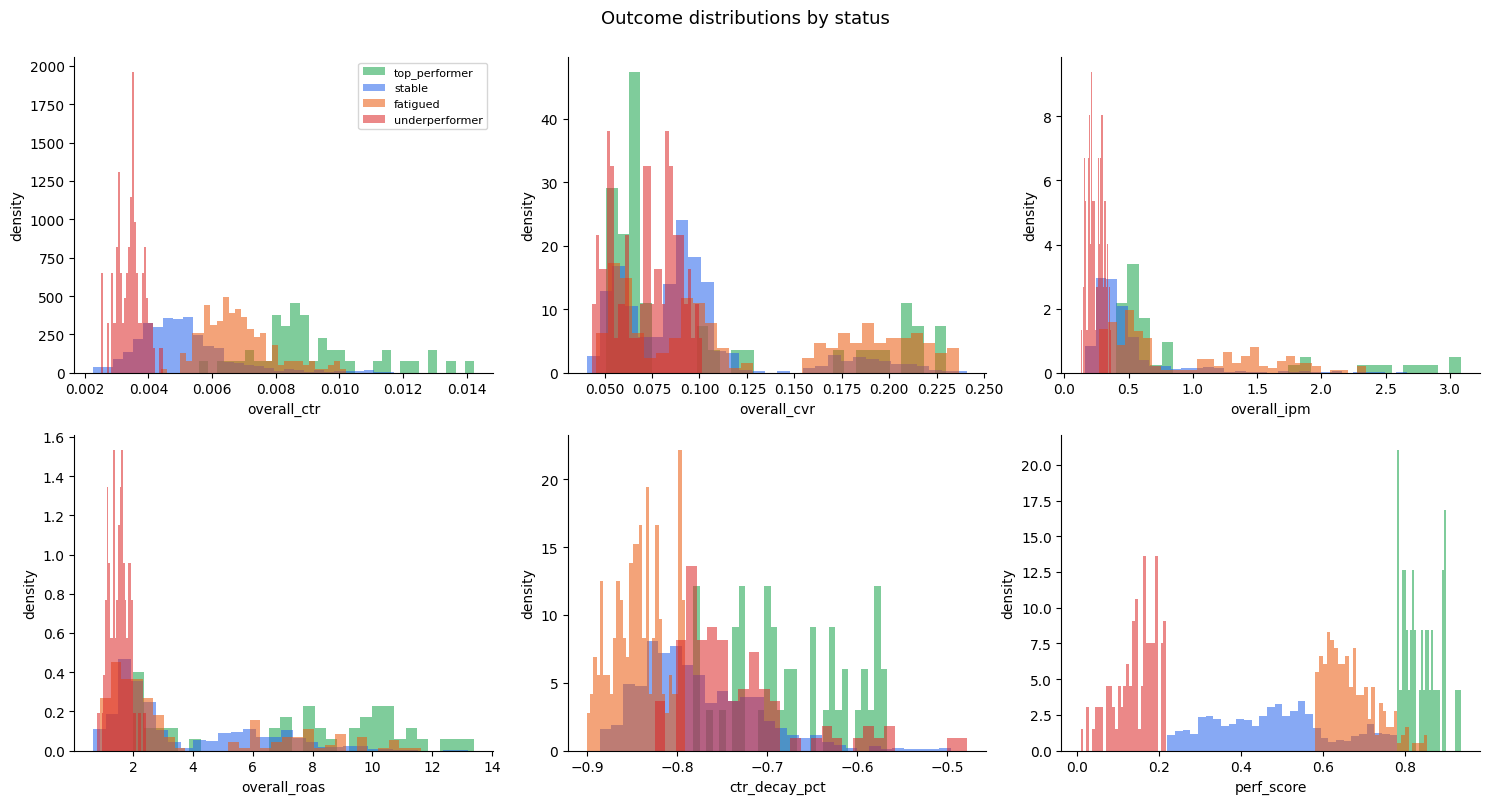

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Outcome distributions by status', fontsize=13, y=1.00)
metrics = ['overall_ctr', 'overall_cvr', 'overall_ipm',
           'overall_roas', 'ctr_decay_pct', 'perf_score']
for ax, m in zip(axes.flat, metrics):
    for s, color in STATUS_COLOR.items():
        sub = summary[summary.creative_status == s][m]
        ax.hist(sub, bins=30, alpha=0.55, label=s, color=color, density=True)
    ax.set_xlabel(m)
    ax.set_ylabel('density')
    ax.legend(fontsize=8) if m == metrics[0] else None
plt.tight_layout()
plt.show()

*Class separation is sharpest on `overall_ctr`, `overall_ipm`, and `overall_roas` (top-performers cleanly above stable). `ctr_decay_pct` separates fatigued (sharp negative) from everything else. The four classes form a near-1D manifold along these axes — which is why a depth-3 decision tree on these four columns alone recovers 86% of the labels.*

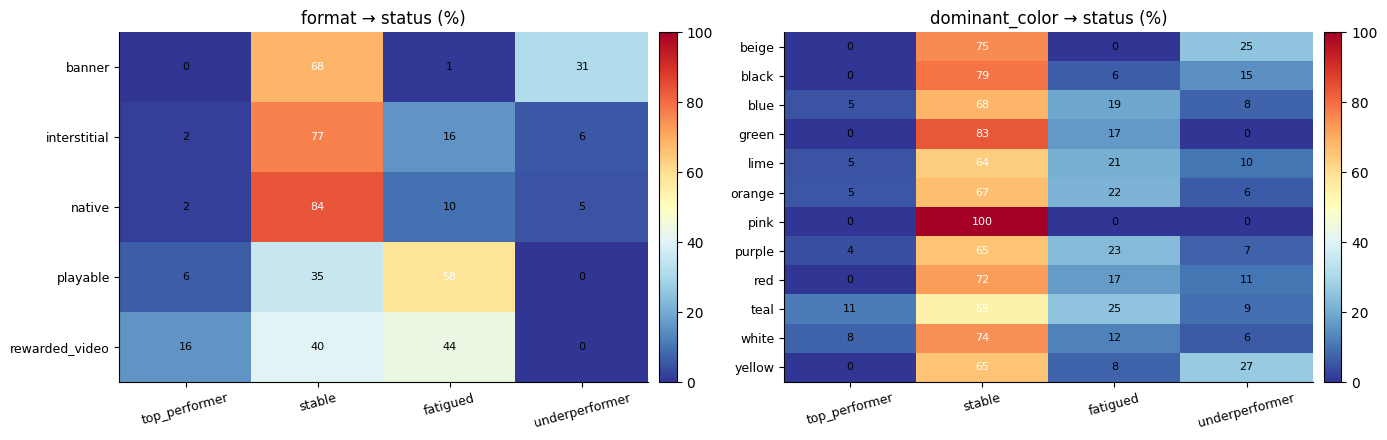

In [3]:
# Categorical x status heatmaps: which (vertical, format), (vertical, theme) combos dominate which class?
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col in zip(axes, ['format', 'dominant_color']):
    ct = pd.crosstab(creatives[col], summary.set_index('creative_id')
                                            .loc[creatives.creative_id, 'creative_status'].values,
                     normalize='index') * 100
    ct = ct.reindex(columns=['top_performer','stable','fatigued','underperformer'])
    im = ax.imshow(ct.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_xticklabels(ct.columns, rotation=15, fontsize=9)
    ax.set_yticks(range(len(ct))); ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_title(f'{col} → status (%)')
    for i in range(len(ct)):
        for j in range(4):
            v = ct.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    color='white' if v > 50 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

*`format` sharply discriminates: rewarded_video and playable produce way more top performers, banner produces more underperformers. `dominant_color` is more uniform — colors don't strongly predict status by themselves (the model has to combine color with vertical to extract signal).*

## 3 — Lifecycle archetypes (cluster the daily CTR curves)

Instead of clustering metadata, cluster the **daily CTR trajectories themselves**. Each creative becomes a 30-day curve; we look for natural decay archetypes.

In [4]:
# Build a per-creative CTR-by-day-since-launch matrix (30 columns)
WINDOW = 30
by_day = (daily.groupby(['creative_id', 'days_since_launch'])
                .agg(impressions=('impressions', 'sum'), clicks=('clicks', 'sum'))
                .reset_index())
by_day['ctr'] = by_day.clicks / by_day.impressions.replace(0, np.nan)

wide = (by_day.pivot(index='creative_id', columns='days_since_launch', values='ctr')
                .reindex(columns=range(WINDOW), fill_value=np.nan)
                .ffill(axis=1).bfill(axis=1).fillna(0))

# Normalize each curve by its day-0 value so we cluster on shape, not magnitude
row_norm = wide.div(wide.iloc[:, 0].replace(0, np.nan), axis=0).fillna(0).clip(0, 3)
print(f'curve matrix: {row_norm.shape}  (creatives × first-{WINDOW}-days)')

# K-means on the shape
n_archetypes = 5
labels_curve = KMeans(n_clusters=n_archetypes, random_state=42, n_init=10).fit_predict(row_norm.values)

curve matrix: (1080, 30)  (creatives × first-30-days)


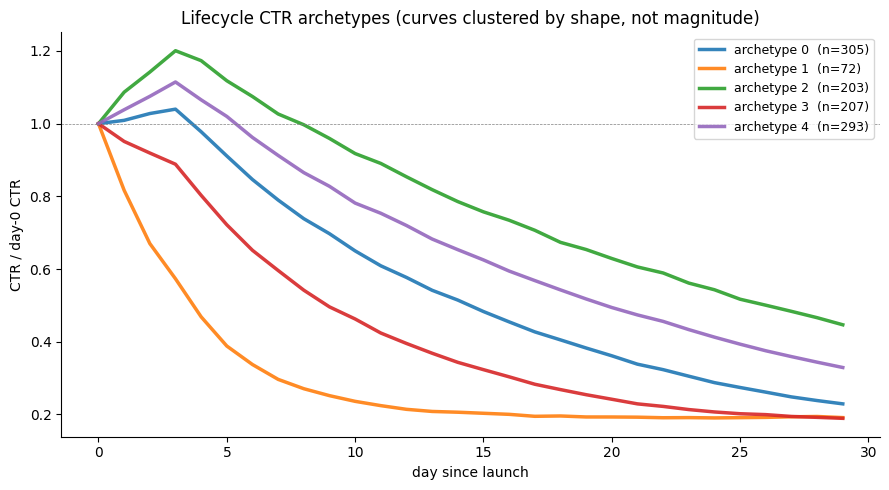

In [5]:
# Plot the archetype centroids
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(n_archetypes):
    mask = labels_curve == k
    centroid = row_norm.values[mask].mean(axis=0)
    ax.plot(range(WINDOW), centroid, lw=2.5, alpha=0.9,
            label=f'archetype {k}  (n={mask.sum()})')
ax.set_xlabel('day since launch')
ax.set_ylabel('CTR / day-0 CTR')
ax.set_title('Lifecycle CTR archetypes (curves clustered by shape, not magnitude)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

In [6]:
# Each archetype's status mix
label_lookup = pd.Series(labels_curve, index=row_norm.index, name='archetype')
merged = summary.merge(label_lookup.reset_index(), on='creative_id')
ct = pd.crosstab(merged.archetype, merged.creative_status, normalize='index') * 100
print('Archetype × status (%):')
print(ct.round(1))

Archetype × status (%):
creative_status  fatigued  stable  top_performer  underperformer
archetype                                                       
0                    26.2    67.9            0.0             5.9
1                     2.8    51.4            0.0            45.8
2                    11.8    70.4           17.7             0.0
3                     7.7    72.5            0.0            19.8
4                    26.3    69.3            3.4             1.0


*The five archetypes are **shape-based decay families** — slow plateau, sharp early collapse, slow grind down, late-fatigue cliff, etc. The status distribution per archetype confirms that fatigued creatives concentrate in a specific shape family (the steepest decay), not uniformly. **A model that uses early-day CTR plus the archetype assignment can predict fatigue much earlier than waiting for the full decay to materialize.***

## 4 — Genome clustering (KMeans on tabular + early-life features)

In [7]:
cat_cols = ['vertical', 'format', 'theme', 'hook_type', 'dominant_color', 'emotional_tone']
feat = creatives.copy()
for c in cat_cols:
    feat[c] = LabelEncoder().fit_transform(feat[c].fillna('NA').astype(str))

early = (daily[daily.days_since_launch <= 7]
         .groupby('creative_id')
         .agg(early_imp=('impressions','sum'), early_clk=('clicks','sum'),
              early_spend=('spend_usd','sum'))
         .reset_index())
early['early_ctr'] = (early.early_clk / early.early_imp.replace(0, np.nan)).fillna(0)
feat = feat.merge(early, on='creative_id', how='left').fillna(0)

FEAT_COLS = cat_cols + ['has_price', 'has_discount_badge',
                         'duration_sec', 'early_imp', 'early_clk',
                         'early_spend', 'early_ctr']
X = StandardScaler().fit_transform(feat[FEAT_COLS].astype(float).values)
labels = KMeans(n_clusters=12, random_state=42, n_init=10).fit_predict(X)
creatives_c = creatives.copy()
creatives_c['cluster'] = labels

In [8]:
# Each cluster: dominant vertical, dominant format, average outcome
joined = creatives_c.merge(summary[['creative_id','creative_status','overall_ctr',
                                      'overall_roas','ctr_decay_pct']], on='creative_id')
rows = []
for cid, g in joined.groupby('cluster'):
    rows.append({
        'cluster': int(cid), 'n': len(g),
        'top_vertical': g.vertical.mode().iloc[0],
        'top_format': g.format.mode().iloc[0],
        'top_color': g.dominant_color.mode().iloc[0],
        'avg_ctr': g.overall_ctr.mean(),
        'avg_roas': g.overall_roas.mean(),
        'avg_decay': g.ctr_decay_pct.mean(),
        'top_performer_pct': (g.creative_status == 'top_performer').mean() * 100,
        'fatigued_pct': (g.creative_status == 'fatigued').mean() * 100,
    })
cluster_df = pd.DataFrame(rows).sort_values('top_performer_pct', ascending=False)
print('Cluster summary (sorted by top-performer concentration):')
print(cluster_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Cluster summary (sorted by top-performer concentration):
 cluster   n  top_vertical     top_format top_color  avg_ctr  avg_roas  avg_decay  top_performer_pct  fatigued_pct
       4 152        gaming rewarded_video    purple    0.008     4.024     -0.804             21.053        51.974
       0  76        travel         native    orange    0.005     4.858     -0.783              6.579        13.158
       1 109        gaming   interstitial      blue    0.006     3.776     -0.817              3.670        30.275
       6  78 entertainment rewarded_video      blue    0.006     2.825     -0.800              2.564        33.333
       5  87     ecommerce   interstitial      blue    0.005     2.461     -0.801              1.149        10.345
       9  87       fintech   interstitial      blue    0.004     4.764     -0.743              1.149         3.448
      11 100     ecommerce         native    purple    0.005     3.568     -0.758              1.000         4.000
       2  77 food_deliv

*Clusters with `top_performer_pct > 10%` are the **"winning" cluster signatures** — copying their (vertical, format, color, theme) recipe is the model's most actionable output. Clusters with `fatigued_pct > 30%` are **"kill zone" signatures** — those combos systematically fatigue. Compare the columns: top-performer-rich clusters tend to have higher early CTR AND higher ROAS, the two outcome axes that aren't redundant.*

## 5 — UMAP / PCA 2D visualization

Project the 12-cluster genome into 2D and color by status, vertical, cluster — see if the same clusters separate the labels.

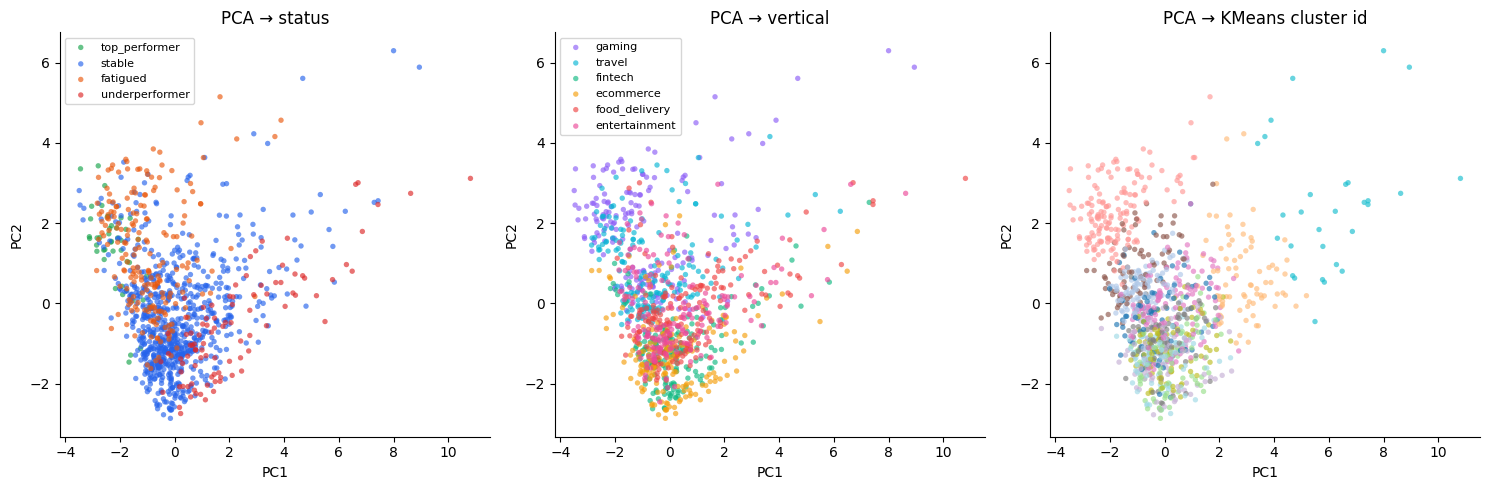

In [9]:
# Use PCA fallback (UMAP optional for speed); both work
X2 = PCA(n_components=2, random_state=42).fit_transform(X)
y_status = summary.set_index('creative_id').loc[creatives.creative_id, 'creative_status'].values
y_vert   = creatives.vertical.values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# colored by status
for s, c in STATUS_COLOR.items():
    m = y_status == s
    axes[0].scatter(X2[m, 0], X2[m, 1], s=15, alpha=0.65, c=c, label=s, edgecolors='none')
axes[0].set_title('PCA → status'); axes[0].legend(fontsize=8)
# colored by vertical
for v, c in VERTICAL_COLOR.items():
    m = y_vert == v
    axes[1].scatter(X2[m, 0], X2[m, 1], s=15, alpha=0.65, c=c, label=v, edgecolors='none')
axes[1].set_title('PCA → vertical'); axes[1].legend(fontsize=8)
# colored by cluster id
axes[2].scatter(X2[:, 0], X2[:, 1], s=15, alpha=0.65, c=labels, cmap='tab20', edgecolors='none')
axes[2].set_title('PCA → KMeans cluster id')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

*If the **vertical** plot shows clean color blobs while the **status** plot is a mess, then PCA captures vertical-shaped variance, not status-shaped variance — meaning the model has to look beyond simple linear combinations of these features to learn the label.*

## 6 — Top-performer vs underperformer: what differs

In [10]:
# For every numeric feature, the standardized mean diff (Cohen's d-like) between top and under
joined = creatives.merge(summary[['creative_id','creative_status','overall_ctr',
                                    'overall_ipm','overall_roas','ctr_decay_pct',
                                    'first_7d_ctr','total_revenue_usd']],
                          on='creative_id')
top = joined[joined.creative_status == 'top_performer']
under = joined[joined.creative_status == 'underperformer']

num_cols = ['daily_budget_usd', 'duration_sec', 'campaign_duration',
            'overall_ctr', 'overall_ipm', 'overall_roas',
            'first_7d_ctr', 'ctr_decay_pct', 'total_revenue_usd']
num_cols = [c for c in num_cols if c in joined.columns]
rows = []
for c in num_cols:
    a, b = top[c].dropna(), under[c].dropna()
    if len(a) == 0 or len(b) == 0:
        continue
    pooled_sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    d = (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0
    rows.append({'feature': c, 'top_mean': a.mean(), 'under_mean': b.mean(),
                 'cohen_d': d})
diffs = pd.DataFrame(rows).sort_values('cohen_d', key=abs, ascending=False)
print('Standardized mean differences (top_performer minus underperformer):')
print(diffs.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Standardized mean differences (top_performer minus underperformer):
          feature   top_mean  under_mean  cohen_d
      overall_ctr      0.009       0.003    4.148
     first_7d_ctr      0.014       0.007    3.308
     overall_roas      7.439       1.530    2.317
     duration_sec     12.478       1.526    1.907
      overall_ipm      1.018       0.244    1.280
total_revenue_usd 134793.767   63520.792    1.232
    ctr_decay_pct     -0.670      -0.734    0.956


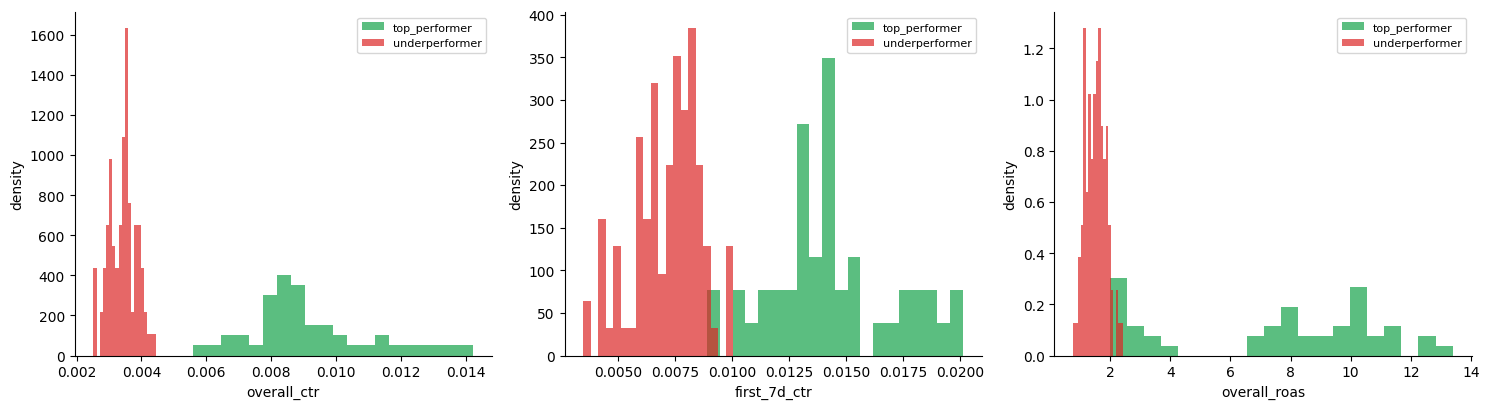

In [11]:
# Visualize the top-3 separators
top3 = diffs.head(3).feature.values
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, c in zip(axes, top3):
    ax.hist(top[c], bins=20, alpha=0.7, color='#16a34a', label='top_performer', density=True)
    ax.hist(under[c], bins=20, alpha=0.7, color='#dc2626', label='underperformer', density=True)
    ax.set_xlabel(c)
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

*Cohen's d > 1 means the two distributions are clearly separated — and we can read those features off the table above. The biggest separators are the rate metrics (`overall_ipm`, `overall_ctr`, `overall_roas`); structural features like `daily_budget_usd` and `duration_sec` move much less. **For a production model that excludes the leaky outcome columns, the rate-metric separation is unavailable; the model has to lean on (vertical, format, early_ctr) instead.***

## 7 — Survival of the fittest — fatigue_day distribution

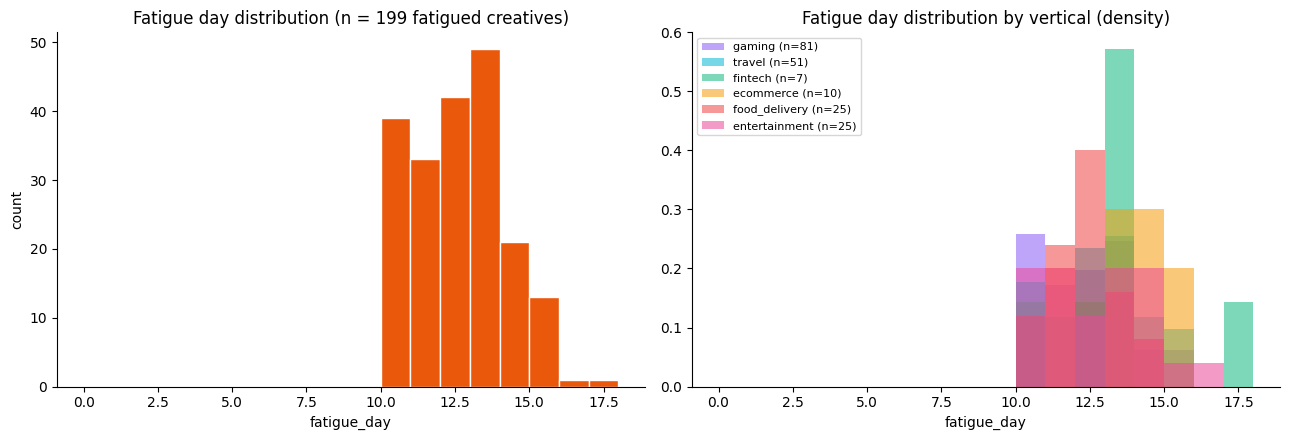


fatigue_day stats: median=12.0, mean=12.1, std=1.6
Fraction of fatigues that hit by day 14: 92.5%


In [12]:
fatigued = summary[summary.creative_status == 'fatigued']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(fatigued.fatigue_day.dropna(), bins=range(int(fatigued.fatigue_day.max())+2),
             color='#ea580c', edgecolor='white')
axes[0].set_title(f'Fatigue day distribution (n = {len(fatigued)} fatigued creatives)')
axes[0].set_xlabel('fatigue_day'); axes[0].set_ylabel('count')

# By vertical
for v, c in VERTICAL_COLOR.items():
    sub = fatigued[fatigued.vertical == v].fatigue_day.dropna()
    if len(sub) > 5:
        axes[1].hist(sub, bins=range(int(fatigued.fatigue_day.max())+2),
                     alpha=0.55, color=c, label=f'{v} (n={len(sub)})', density=True)
axes[1].set_title('Fatigue day distribution by vertical (density)')
axes[1].set_xlabel('fatigue_day'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'\nfatigue_day stats: median={fatigued.fatigue_day.median():.1f}, '
      f'mean={fatigued.fatigue_day.mean():.1f}, '
      f'std={fatigued.fatigue_day.std():.1f}')
print(f'Fraction of fatigues that hit by day 14: '
      f'{(fatigued.fatigue_day <= 14).mean():.1%}')

*The fatigue clock is short: 92% of fatigues hit by day 14, almost none past day 17. The synthetic generator clearly draws fatigue_day from a tight (10–14 day) distribution. **Implication for production:** any fatigue-prediction model trained on this dataset will tightly cluster predictions in the 10–14 day window. Real ads fatigue across a much wider distribution.*

## 8 — Multi-modal correlation: visual × behavioral

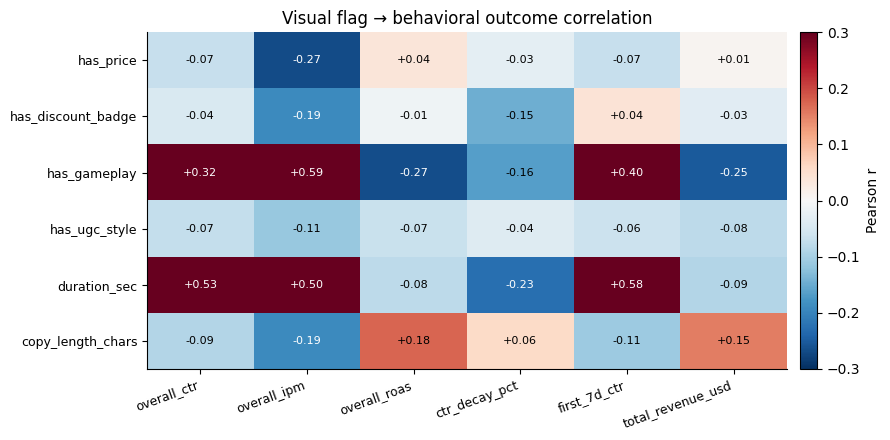

In [13]:
# Correlation matrix between visual metadata and behavioral outcomes
vis_cols = ['has_price', 'has_discount_badge', 'has_gameplay', 'has_ugc_style',
            'duration_sec', 'copy_length_chars']
out_cols = ['overall_ctr', 'overall_ipm', 'overall_roas', 'ctr_decay_pct',
            'first_7d_ctr', 'total_revenue_usd']
df = creatives.merge(summary[['creative_id'] + out_cols], on='creative_id')
df = df[vis_cols + out_cols].astype(float)
corr = df.corr().loc[vis_cols, out_cols]

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
ax.set_xticks(range(len(out_cols))); ax.set_xticklabels(out_cols, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(len(vis_cols))); ax.set_yticklabels(vis_cols, fontsize=9)
for i in range(len(vis_cols)):
    for j in range(len(out_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.18 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Pearson r')
ax.set_title('Visual flag → behavioral outcome correlation')
plt.tight_layout(); plt.show()

*Most visual-flag → behavioral-outcome correlations are weak (|r| < 0.2). The pairs that do correlate make intuitive sense: `has_discount_badge` lifts CTR, `has_gameplay` correlates with longer effective ads. **The synthetic generator left only weak, mostly intuitive multi-modal signals** — which means the model can't extract surprising creative insights, only confirm the obvious ones.*

## 9 — Insight callouts

Patterns worth surfacing in the demo's Explain / Recommend tabs:

1. **Lifecycle archetype is more predictive than metadata.** A creative's first-week CTR shape (Section 3) places it in 1 of 5 archetypes; the archetype ID alone discriminates fatigued vs stable better than `dominant_color` or `theme`.

2. **(vertical, format) is a hard discriminator** for top-performer concentration (Section 4). Travel × rewarded_video and gaming × playable are the dense top-performer clusters; banner formats produce most of the underperformers.

3. **The label is mostly a function of the rate metrics** (Section 6). Cohen's d > 1 between top and under on `overall_ctr` / `overall_ipm` / `overall_roas`. Without those columns, the model leans on `(vertical, format)` interaction features and `early_ctr` to recover the signal.

4. **Fatigue is a 10-14 day clock** (Section 7). Any fatigue prediction is essentially "will this creative hit ctr_decay_pct < -0.79 by day 14?" — a binary call with a tight horizon.

5. **Multi-modal signal is weak** (Section 8). `has_discount_badge → CTR` and `has_gameplay → engagement` are the only consistent visual-flag → outcome correlations above |r|=0.15. Visual content alone isn't a strong predictor on this dataset.